In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# Constants

In [11]:
RANDOM_STATE = 42
TARGET_COLUMN = "quality"
TYPE_COLUMN = "type"

In [ ]:
# Data Loading and Preprocessing

In [13]:
def load_and_prepare_data(csv_path):
    # Load dataset
    df = pd.read_csv(csv_path)

    # Encode wine type if the 'type' column exists
    if TYPE_COLUMN in df.columns:
        df[TYPE_COLUMN] = df[TYPE_COLUMN].map({"white": 0, "red": 1})
    else:
        print(f"Warning: Column '{TYPE_COLUMN}' not found. Proceeding without it.")

    # Convert quality into binary classes
    # quality >= 7 --> High Quality (1)
    # quality < 7  --> Low Quality (0)
    df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(lambda x: 1 if x >= 7 else 0)

    # Split features and target
    X = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE
    )

    # Save class distribution before resampling for graph
    y_train_before_resampling = y_train.copy()

    # Handle missing values using KNN Imputer
    imputer = KNNImputer(n_neighbors=3)

    X_train = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    # Scale numerical columns
    # Do not scale 'type' column if it exists
    if TYPE_COLUMN in X_train.columns:
        numeric_columns = [col for col in X_train.columns if col != TYPE_COLUMN]
    else:
        numeric_columns = list(X_train.columns)

    scaler = StandardScaler()
    X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
    X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

    # Handle class imbalance only on training data
    rus = RandomUnderSampler(random_state=RANDOM_STATE)
    X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

    X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
    y_train_resampled = pd.Series(y_train_resampled, name=TARGET_COLUMN)

    return X_train_resampled, X_test, y_train_resampled, y_test, y_train_before_resampling


In [ ]:
# Load Prepared Data

In [15]:
X_train, X_test, y_train, y_test, y_train_before_resampling = load_and_prepare_data("../../winequalityN.csv")

In [ ]:
# Create KNN Model

In [17]:
model = KNeighborsClassifier()

In [ ]:
# Define Hyperparameter Grid

In [19]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski", "euclidean", "manhattan"],
    "p": [1, 2]
}

In [ ]:
# Hyperparameter Tuning Using Randomized Search

In [21]:
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="accuracy",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search.fit(X_train, y_train)


,estimator,KNeighborsClassifier()
,param_distributions,"{'metric': ['minkowski', 'euclidean', ...], 'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
# Best Model Selection + Prediction

In [23]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
# Print Model Results

In [25]:
print("=== K-Nearest Neighbors ===")
print("Best Parameters:", search.best_params_)
print("Best CV Score:", search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

=== K-Nearest Neighbors ===
Best Parameters: {'weights': 'uniform', 'p': 2, 'n_neighbors': 11, 'metric': 'minkowski'}
Best CV Score: 0.757599837000815
Test Accuracy: 0.7092307692307692
Precision: 0.3898916967509025
Recall: 0.84375
F1 Score: 0.5333333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.68      0.79      1044
           1       0.39      0.84      0.53       256

    accuracy                           0.71      1300
   macro avg       0.67      0.76      0.66      1300
weighted avg       0.84      0.71      0.74      1300



In [ ]:
# Accuracy VS K Value

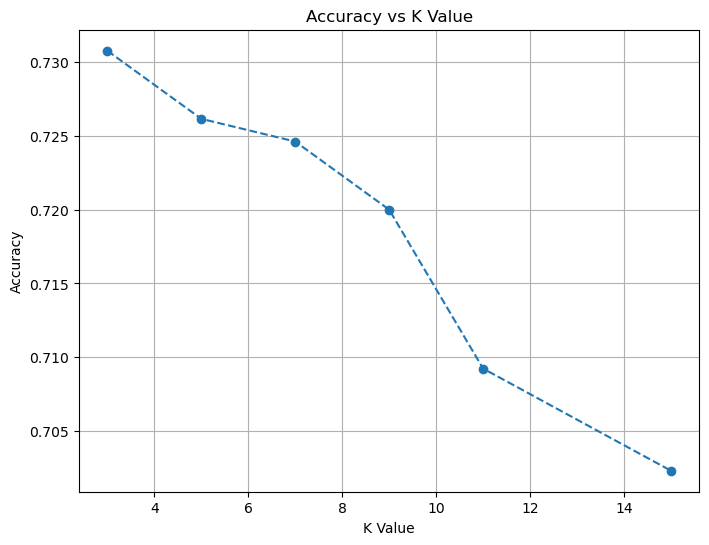

In [27]:
k_values = param_grid["n_neighbors"]
accuracies = []

for k in k_values:
    temp_model = KNeighborsClassifier(
        n_neighbors=k,
        weights=search.best_params_["weights"],
        metric=search.best_params_["metric"],
        p=search.best_params_["p"]
    )
    temp_model.fit(X_train, y_train)
    y_pred_k = temp_model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.title("Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [ ]:
# Confusion Matrix

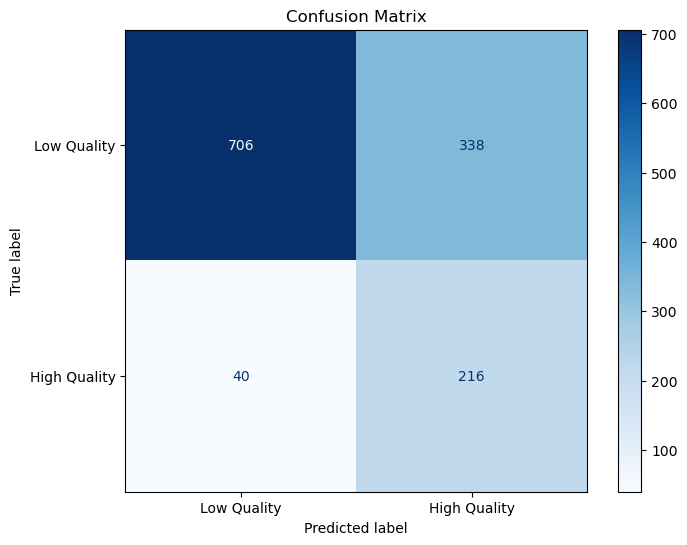

In [29]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Quality", "High Quality"]
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# ROC Curve

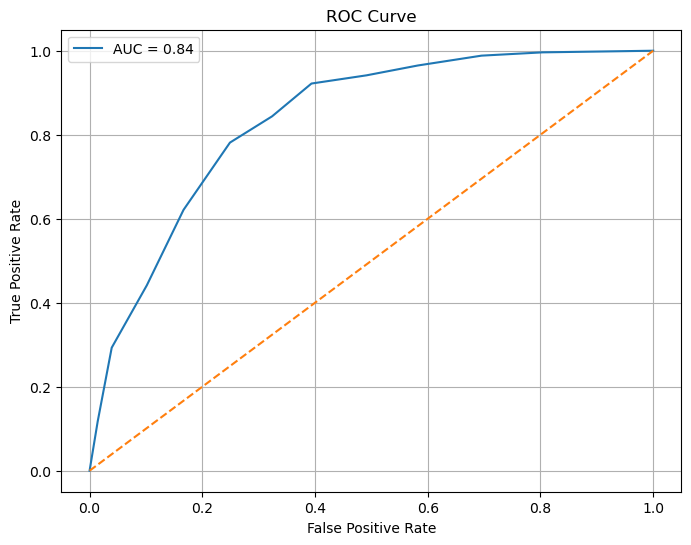

In [31]:
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Class Distribution Before and After Resampling

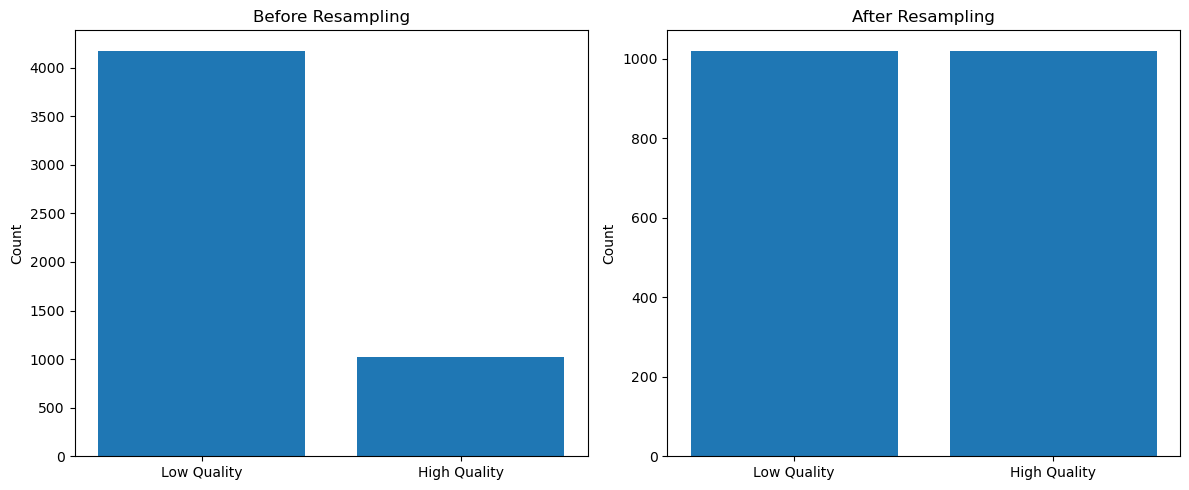

In [33]:
before_counts = y_train_before_resampling.value_counts().sort_index()
after_counts = y_train.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["Low Quality", "High Quality"], before_counts.values)
axes[0].set_title("Before Resampling")
axes[0].set_ylabel("Count")

axes[1].bar(["Low Quality", "High Quality"], after_counts.values)
axes[1].set_title("After Resampling")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()